In [3]:
import json
import csv
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [4]:
f_train = open("train.json")
  
dat_train = json.load(f_train)

#### Categories
The "categories" object contains a list of categories and each of those belongs to a supercategory. The category is a combination of the pathology type and pathology subtype (e.g. Meniscus Tear - Myxoid). There may be plans in the future to make tissue type an additional stratification level. This would primarily affect the "Cartilage Lesion" categories, which are currently only separated by grade, but not by tissue. If you would like to do tissues as well, you will have to reindex your categories (and annotations).

In [5]:
categories = pd.json_normalize(dat_train["categories"])
categories

,supercategory,supercategory_id,id,name
0,Meniscal Tear,1,1,Meniscal Tear (Myxoid)
1,Meniscal Tear,1,2,Meniscal Tear (Horizontal)
2,Meniscal Tear,1,3,Meniscal Tear (Radial)
3,Meniscal Tear,1,4,Meniscal Tear (Vertical/Longitudinal)
4,Meniscal Tear,1,5,Meniscal Tear (Oblique)
5,Meniscal Tear,1,6,Meniscal Tear (Complex)
6,Meniscal Tear,1,7,Meniscal Tear (Flap)
7,Meniscal Tear,1,8,Meniscal Tear (Extrusion)
8,Ligament Tear,2,9,Ligament Tear (Low-Grade Sprain)
9,Ligament Tear,2,10,Ligament Tear (Moderate Grade Sprain or Mucoid...


In [18]:
supercat = categories.drop(["id", "name"], axis=1)

In [21]:
supercat = supercat.drop_duplicates(subset = ["supercategory"]).reset_index(drop=True)

In [22]:
supercat

,supercategory,supercategory_id
0,Meniscal Tear,1
1,Ligament Tear,2
2,Cartilage Lesion,3
3,Effusion,4


In [23]:
cat_dict = dict(zip(categories.id, categories.name))

In [24]:
cat_id_to_supercat_id = dict(zip(categories.id, categories.supercategory_id))

In [25]:
supercat_dict = dict(zip(categories.supercategory_id, categories.supercategory))

#### Tissues
The "tissues" object contains a list of tissues that are referenced in each annotation label

In [26]:
tissues = pd.json_normalize(dat_train["tissues"])
tissues

,id,name
0,1,Meniscus
1,2,ACL
2,3,PCL
3,4,Femoral Cartilage
4,5,Patellar Cartilage
5,6,Tibial Cartilage


In [27]:
tissue_dict = dict(zip(tissues.id, tissues.name))

#### Annotations
The "annotations" section has several components, which makes it a bit trickier to understand. It contains a list of every individual detection (object) annotation from every scan in the dataset. For example, if there are 10 Grade 2A cartilage lesions in a single scan, there will be 10 annotations corresponding to these individual lesions for that scan alone.

The image id corresponds to a specific scan in the dataset.

The bounding box (bbox) format is [top left X position, top left Y position, top left Z position, deltaX, deltaY, deltaZ]. NOTE: X corresponds to row (SI), Y to column (AP), and Z (RL/LR) to depth.

The category id corresponds to a single category specified in the categories section.

Each annotation also has an id (unique to all other annotations in the dataset).

The confidence is on a scale of 0-5, where 0 is not confident at all and 5 is extremely confident. Feel free to filter labels by this scale.

The tissue id corresponds to a single tissue specified in the tissues section.

In [28]:
annotations_train = pd.json_normalize(dat_train["annotations"])
annotations_train

,id,image_id,category_id,tissue_id,bbox,confidence,labeler
0,1,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1
1,2,31,12,4,"[227.0, 156.0, 55.0, 20.0, 12.0, 13.0]",4.0,1
2,3,31,13,4,"[246.0, 166.0, 92.0, 63.0, 23.0, 17.0]",4.0,1
3,4,32,16,-1,"[45.0, 109.0, 30.0, 264.0, 121.0, 107.0]",5.0,1
4,5,32,2,1,"[322.0, 216.0, 42.0, 4.0, 11.0, 8.0]",3.0,1
...,...,...,...,...,...,...,...
237,238,21,13,6,"[384.0, 281.0, 97.0, 32.0, 64.0, 27.0]",3.0,2
238,239,23,13,4,"[361.0, 218.0, 92.0, 21.0, 79.0, 23.0]",3.0,2
239,240,29,9,2,"[299.0, 244.0, 72.0, 84.0, 78.0, 22.0]",3.0,2
240,241,29,12,5,"[276.0, 116.0, 59.0, 59.0, 35.0, 49.0]",3.0,2


In [29]:
annotations_train["split"] = "train"
annotations_train

,id,image_id,category_id,tissue_id,bbox,confidence,labeler,split
0,1,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,train
1,2,31,12,4,"[227.0, 156.0, 55.0, 20.0, 12.0, 13.0]",4.0,1,train
2,3,31,13,4,"[246.0, 166.0, 92.0, 63.0, 23.0, 17.0]",4.0,1,train
3,4,32,16,-1,"[45.0, 109.0, 30.0, 264.0, 121.0, 107.0]",5.0,1,train
4,5,32,2,1,"[322.0, 216.0, 42.0, 4.0, 11.0, 8.0]",3.0,1,train
...,...,...,...,...,...,...,...,...
237,238,21,13,6,"[384.0, 281.0, 97.0, 32.0, 64.0, 27.0]",3.0,2,train
238,239,23,13,4,"[361.0, 218.0, 92.0, 21.0, 79.0, 23.0]",3.0,2,train
239,240,29,9,2,"[299.0, 244.0, 72.0, 84.0, 78.0, 22.0]",3.0,2,train
240,241,29,12,5,"[276.0, 116.0, 59.0, 59.0, 35.0, 49.0]",3.0,2,train


In [30]:
f_val = open("val.json")
  
dat_val = json.load(f_val)

annotations_val = pd.json_normalize(dat_val["annotations"])
annotations_val["split"] = "val"
annotations_val

,id,image_id,category_id,tissue_id,bbox,confidence,labeler,split
0,1,19,16,-1,"[88.0, 19.0, 38.0, 247.0, 240.0, 92.0]",5.0,1,val
1,2,19,5,1,"[328.0, 295.0, 104.0, 6.0, 11.0, 12.0]",4.0,1,val
2,3,19,11,2,"[257.0, 245.0, 72.0, 40.0, 34.0, 16.0]",4.0,1,val
3,4,21,2,1,"[355.0, 208.0, 41.0, 12.0, 21.0, 15.0]",4.0,1,val
4,5,32,16,-1,"[5.0, 111.0, 66.0, 227.0, 103.0, 61.0]",4.0,1,val
...,...,...,...,...,...,...,...,...
99,100,3,16,-1,"[10.0, 100.0, 57.0, 289.0, 109.0, 73.0]",4.0,2,val
100,101,7,2,1,"[314.0, 220.0, 54.0, 21.0, 29.0, 12.0]",2.0,2,val
101,102,7,12,6,"[325.0, 228.0, 96.0, 12.0, 27.0, 13.0]",3.0,2,val
102,103,7,12,5,"[199.0, 124.0, 49.0, 54.0, 34.0, 44.0]",4.0,2,val


In [31]:
f_test = open("test.json")
  
dat_test = json.load(f_test)

annotations_test = pd.json_normalize(dat_test["annotations"])
annotations_test["split"] = "test"
annotations_test

,id,image_id,category_id,tissue_id,bbox,confidence,labeler,split
0,1,18,16,-1,"[109.0, 131.0, 20.0, 167.0, 120.0, 38.0]",5.0,1,test
1,2,19,16,-1,"[348.0, 194.0, 89.0, 30.0, 35.0, 23.0]",5.0,1,test
2,3,19,3,1,"[308.0, 325.0, 38.0, 7.0, 17.0, 8.0]",2.0,1,test
3,4,19,9,2,"[256.0, 268.0, 69.0, 27.0, 32.0, 18.0]",0.0,1,test
4,5,20,16,-1,"[157.0, 75.0, 18.0, 212.0, 148.0, 119.0]",5.0,1,test
...,...,...,...,...,...,...,...,...
125,126,17,13,5,"[95.0, 83.0, 68.0, 110.0, 52.0, 63.0]",3.0,2,test
126,127,17,12,6,"[259.0, 242.0, 93.0, 32.0, 107.0, 38.0]",3.0,2,test
127,128,17,12,4,"[183.0, 271.0, 94.0, 82.0, 85.0, 27.0]",3.0,2,test
128,129,17,13,4,"[149.0, 224.0, 30.0, 126.0, 107.0, 36.0]",3.0,2,test


In [32]:
annotations = pd.concat([annotations_train, annotations_val, annotations_test])
annotations

,id,image_id,category_id,tissue_id,bbox,confidence,labeler,split
0,1,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,train
1,2,31,12,4,"[227.0, 156.0, 55.0, 20.0, 12.0, 13.0]",4.0,1,train
2,3,31,13,4,"[246.0, 166.0, 92.0, 63.0, 23.0, 17.0]",4.0,1,train
3,4,32,16,-1,"[45.0, 109.0, 30.0, 264.0, 121.0, 107.0]",5.0,1,train
4,5,32,2,1,"[322.0, 216.0, 42.0, 4.0, 11.0, 8.0]",3.0,1,train
...,...,...,...,...,...,...,...,...
125,126,17,13,5,"[95.0, 83.0, 68.0, 110.0, 52.0, 63.0]",3.0,2,test
126,127,17,12,6,"[259.0, 242.0, 93.0, 32.0, 107.0, 38.0]",3.0,2,test
127,128,17,12,4,"[183.0, 271.0, 94.0, 82.0, 85.0, 27.0]",3.0,2,test
128,129,17,13,4,"[149.0, 224.0, 30.0, 126.0, 107.0, 36.0]",3.0,2,test


In [33]:
annotations["category"] = annotations["category_id"].map(cat_dict)
annotations["supercat_id"] = annotations["category_id"].map(cat_id_to_supercat_id) 
annotations["supercategory"] = annotations["supercat_id"].map(supercat_dict) 
annotations["tissues"] = annotations["tissue_id"].map(tissue_dict)
annotations

,id,image_id,category_id,tissue_id,bbox,confidence,labeler,split,category,supercat_id,supercategory,tissues
0,1,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,train,Meniscal Tear (Radial),1,Meniscal Tear,Meniscus
1,2,31,12,4,"[227.0, 156.0, 55.0, 20.0, 12.0, 13.0]",4.0,1,train,Cartilage Lesion (1),3,Cartilage Lesion,Femoral Cartilage
2,3,31,13,4,"[246.0, 166.0, 92.0, 63.0, 23.0, 17.0]",4.0,1,train,Cartilage Lesion (2A),3,Cartilage Lesion,Femoral Cartilage
3,4,32,16,-1,"[45.0, 109.0, 30.0, 264.0, 121.0, 107.0]",5.0,1,train,Effusion,4,Effusion,NaN
4,5,32,2,1,"[322.0, 216.0, 42.0, 4.0, 11.0, 8.0]",3.0,1,train,Meniscal Tear (Horizontal),1,Meniscal Tear,Meniscus
...,...,...,...,...,...,...,...,...,...,...,...,...
125,126,17,13,5,"[95.0, 83.0, 68.0, 110.0, 52.0, 63.0]",3.0,2,test,Cartilage Lesion (2A),3,Cartilage Lesion,Patellar Cartilage
126,127,17,12,6,"[259.0, 242.0, 93.0, 32.0, 107.0, 38.0]",3.0,2,test,Cartilage Lesion (1),3,Cartilage Lesion,Tibial Cartilage
127,128,17,12,4,"[183.0, 271.0, 94.0, 82.0, 85.0, 27.0]",3.0,2,test,Cartilage Lesion (1),3,Cartilage Lesion,Femoral Cartilage
128,129,17,13,4,"[149.0, 224.0, 30.0, 126.0, 107.0, 36.0]",3.0,2,test,Cartilage Lesion (2A),3,Cartilage Lesion,Femoral Cartilage


In [35]:
annotations.loc[annotations["image_id"] == 10]

,id,image_id,category_id,tissue_id,bbox,confidence,labeler,split,category,supercat_id,supercategory,tissues
67,68,10,16,-1,"[113.0, 125.0, 44.0, 85.0, 19.0, 25.0]",4.0,1,train,Effusion,4,Effusion,NaN
68,69,10,13,4,"[225.0, 165.0, 79.0, 17.0, 11.0, 11.0]",4.0,1,train,Cartilage Lesion (2A),3,Cartilage Lesion,Femoral Cartilage
69,70,10,13,4,"[208.0, 144.0, 100.0, 75.0, 47.0, 21.0]",3.0,1,train,Cartilage Lesion (2A),3,Cartilage Lesion,Femoral Cartilage
30,31,10,5,1,"[308.0, 287.0, 33.0, 11.0, 12.0, 10.0]",4.0,1,val,Meniscal Tear (Oblique),1,Meniscal Tear,Meniscus
31,32,10,2,1,"[304.0, 291.0, 104.0, 6.0, 13.0, 7.0]",3.0,1,val,Meniscal Tear (Horizontal),1,Meniscal Tear,Meniscus
32,33,10,13,4,"[219.0, 307.0, 97.0, 42.0, 4.0, 11.0]",2.0,1,val,Cartilage Lesion (2A),3,Cartilage Lesion,Femoral Cartilage
102,103,10,12,5,"[150.0, 132.0, 66.0, 62.0, 28.0, 35.0]",4.0,2,test,Cartilage Lesion (1),3,Cartilage Lesion,Patellar Cartilage
103,104,10,16,-1,"[8.0, 126.0, 26.0, 293.0, 163.0, 113.0]",4.0,2,test,Effusion,4,Effusion,NaN


In [44]:
test = annotations.loc[annotations["image_id"] == 2]
test

,id,image_id,category_id,tissue_id,bbox,confidence,labeler,split,category,supercat_id,supercategory,tissues
57,58,2,9,3,"[249.0, 258.0, 80.0, 7.0, 6.0, 4.0]",1.0,1,train,Ligament Tear (Low-Grade Sprain),2,Ligament Tear,PCL
58,59,2,16,-1,"[195.0, 36.0, 54.0, 25.0, 6.0, 6.0]",3.0,1,train,Effusion,4,Effusion,NaN
59,60,2,13,5,"[187.0, 109.0, 62.0, 6.0, 3.0, 8.0]",4.0,1,train,Cartilage Lesion (2A),3,Cartilage Lesion,Patellar Cartilage
69,70,2,6,1,"[263.0, 323.0, 29.0, 65.0, 40.0, 38.0]",3.0,2,val,Meniscal Tear (Complex),1,Meniscal Tear,Meniscus
70,71,2,7,1,"[293.0, 327.0, 56.0, 18.0, 16.0, 5.0]",2.0,2,val,Meniscal Tear (Flap),1,Meniscal Tear,Meniscus
71,72,2,10,3,"[148.0, 278.0, 61.0, 201.0, 91.0, 23.0]",1.0,2,val,Ligament Tear (Moderate Grade Sprain or Mucoid...,2,Ligament Tear,PCL
72,73,2,16,-1,"[66.0, 106.0, 138.0, 77.0, 120.0, -58.0]",4.0,2,val,Effusion,4,Effusion,NaN
73,74,2,14,4,"[313.0, 230.0, 40.0, 11.0, 60.0, 12.0]",4.0,2,val,Cartilage Lesion (2B),3,Cartilage Lesion,Femoral Cartilage
61,62,2,6,1,"[279.0, 175.0, 86.0, 38.0, 134.0, 33.0]",3.0,2,test,Meniscal Tear (Complex),1,Meniscal Tear,Meniscus
62,63,2,13,5,"[168.0, 86.0, 38.0, 83.0, 44.0, 47.0]",4.0,2,test,Cartilage Lesion (2A),3,Cartilage Lesion,Patellar Cartilage


In [45]:
test = test.drop(["category", "category_id"], axis=1)


In [48]:
test[test.split == "test"]

,id,image_id,tissue_id,bbox,confidence,labeler,split,supercat_id,supercategory,tissues
61,62,2,1,"[279.0, 175.0, 86.0, 38.0, 134.0, 33.0]",3.0,2,test,1,Meniscal Tear,Meniscus
62,63,2,5,"[168.0, 86.0, 38.0, 83.0, 44.0, 47.0]",4.0,2,test,3,Cartilage Lesion,Patellar Cartilage
63,64,2,6,"[294.0, 264.0, 46.0, 17.0, 58.0, 20.0]",3.0,2,test,3,Cartilage Lesion,Tibial Cartilage
64,65,2,4,"[277.0, 181.0, 83.0, 31.0, 100.0, 32.0]",3.0,2,test,3,Cartilage Lesion,Femoral Cartilage
65,66,2,4,"[255.0, 150.0, 68.0, 20.0, 33.0, 15.0]",3.0,2,test,3,Cartilage Lesion,Femoral Cartilage
66,67,2,-1,"[73.0, 98.0, 39.0, 228.0, 100.0, 70.0]",4.0,2,test,4,Effusion,NaN


In [14]:
df_plt = annotations.loc[:, ["split", "supercategory", "confidence"]]
df_plt

,split,supercategory,confidence
0,train,Meniscal Tear,3.0
1,train,Cartilage Lesion,4.0
2,train,Cartilage Lesion,4.0
3,train,Effusion,5.0
4,train,Meniscal Tear,3.0
...,...,...,...
125,test,Cartilage Lesion,3.0
126,test,Cartilage Lesion,3.0
127,test,Cartilage Lesion,3.0
128,test,Cartilage Lesion,3.0


(0.0, 250.0)

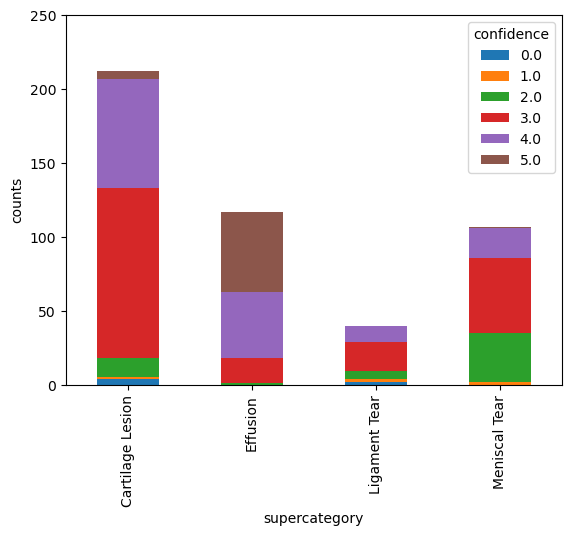

In [15]:
df_plt.drop("split", axis=1).groupby(["supercategory", "confidence"])["confidence"].count().reset_index(name="counts").pivot_table(index = "supercategory", columns = "confidence", values = "counts").plot(kind = "bar", stacked = True)
plt.ylabel("counts")
plt.ylim(0, 250)


In [16]:
df_train = df_plt[df_plt["split"] == "train"].drop("split", axis=1)
df_val = df_plt[df_plt["split"] == "val"].drop("split", axis=1)
df_test = df_plt[df_plt["split"] == "test"].drop("split", axis=1)

In [17]:
df_train_count = df_train.groupby(["supercategory", "confidence"])["confidence"].count().reset_index(name="counts")
df_val_count = df_val.groupby(["supercategory", "confidence"])["confidence"].count().reset_index(name="counts")
df_test_count = df_test.groupby(["supercategory", "confidence"])["confidence"].count().reset_index(name="counts")



Text(0.5, 1.0, 'Train')

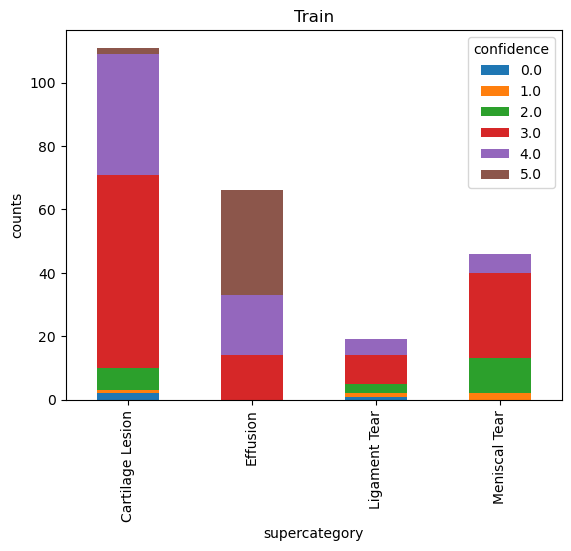

In [18]:
df_train_count.pivot_table(index = "supercategory", columns = "confidence", values = "counts").plot(kind = "bar", stacked = True)
plt.ylabel("counts")
plt.title("Train")


Text(0.5, 1.0, 'Val')

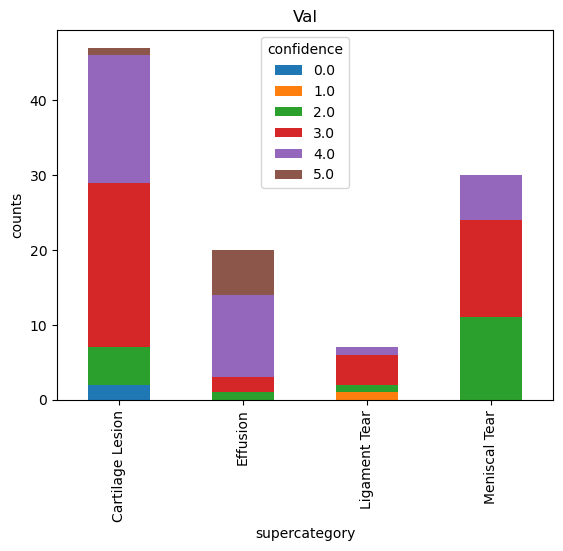

In [19]:
df_val_count.pivot_table(index = "supercategory", columns = "confidence", values = "counts").plot(kind = "bar", stacked = True)
plt.ylabel("counts")
plt.title("Val")


Text(0.5, 1.0, 'Test')

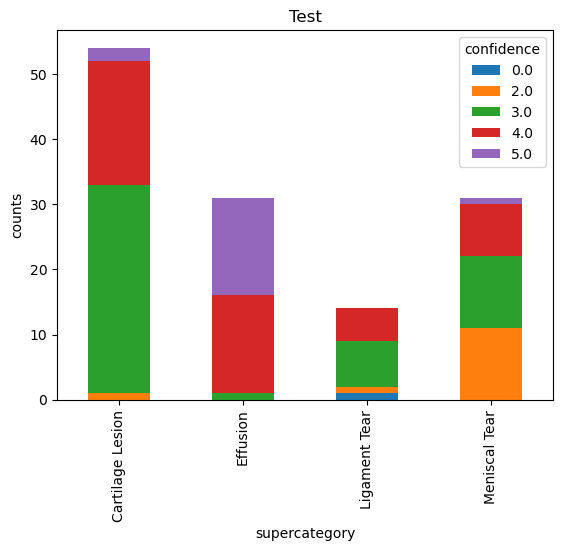

In [20]:
df_test_count.pivot_table(index = "supercategory", columns = "confidence", values = "counts").plot(kind = "bar", stacked = True)
plt.ylabel("counts")
plt.title("Test")
